In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os, time
from pathlib import Path
from dataclasses import dataclass

# Dataset

In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/


In [ ]:
IMG_DIR = os.path.join(path, "img_align_celeba", "img_align_celeba")
print(len(os.listdir(IMG_DIR)))

202599


In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 64

def load_and_preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    
    return image

import glob

image_files = glob.glob(os.path.join(IMG_DIR, "*.jpg"))
image_files = image_files[:8000]  # limit dataset size

print("Number of images used:", len(image_files))

dataset = tf.data.Dataset.from_tensor_slices(image_files)
dataset = dataset.map(load_and_preprocess_image,
                      num_parallel_calls=tf.data.AUTOTUNE)

dataset = dataset.shuffle(5000)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

Number of images used: 8000


I0000 00:00:1770485405.117442      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770485405.123460      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


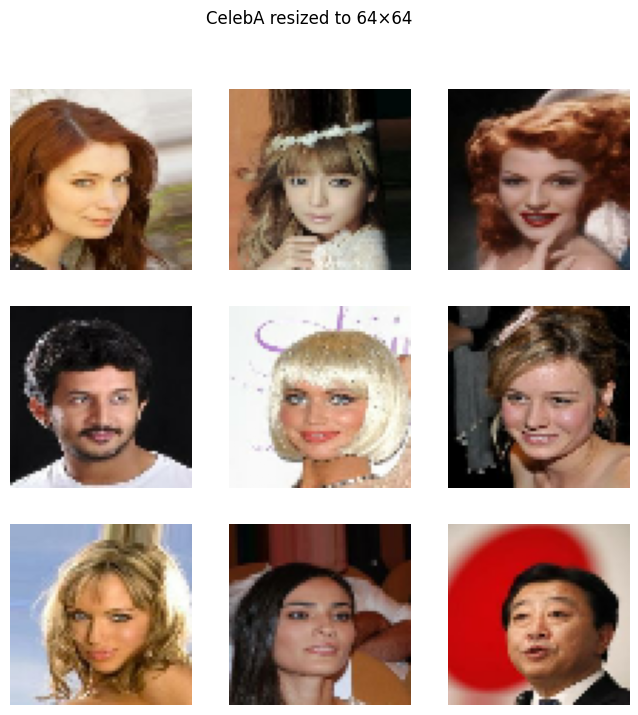

In [6]:
sample_batch = next(iter(dataset))

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow((sample_batch[i]))
    plt.axis("off")
plt.suptitle("CelebA resized to 64×64")
plt.show()

# VAE

## Base Model (d=64)

In [53]:
LATENT_DIM = 64

enc_in = keras.Input(shape=(64,64,3))

x = layers.Conv2D(128, 4, strides=2, padding="same", use_bias=False)(enc_in)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(256, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(512, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(1024, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Flatten()(x)  # 4*4*1024

mu = layers.Dense(LATENT_DIM, name="mu")(x)
logvar = layers.Dense(LATENT_DIM, name="logvar")(x)

encoder = keras.Model(enc_in, [mu, logvar], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │      6,144 │ input_layer_11[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │    524,288 │ re_lu_20[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 8, 8, 512) │  2,097,152 │ re_lu_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 4, 4,      │  8,388,608 │ re_lu_22[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4,      │      4,096 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_23 (ReLU)     │ (None, 4, 4,      │          0 │ batch_normalizat… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 16384)     │          0 │ re_lu_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 64)        │  1,048,640 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logvar (Dense)      │ (None, 64)        │  1,048,640 │ flatten_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,121,152 (50.05 MB)

 Trainable params: 13,117,312 (50.04 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [54]:
dec_in = keras.Input(shape=(LATENT_DIM,))

y = layers.Dense(4*4*1024)(dec_in)
y = layers.Reshape((4,4,1024))(y)

y = layers.Conv2DTranspose(512, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(256, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(3, 4, strides=2, padding="same", use_bias=True)(y)
dec_out = layers.Activation("sigmoid")(y)

decoder = keras.Model(dec_in, dec_out, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16384)          │     1,064,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_24             │ (None, 8, 8, 512)      │     8,388,608 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_25             │ (None, 16, 16, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_26             │ (None, 32, 32, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_27             │ (None, 64, 64, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64, 64, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,084,739 (46.10 MB)

 Trainable params: 12,082,947 (46.09 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [55]:
opt = keras.optimizers.Adam(1e-4)

EPOCHS = 20

loss_history = []
recon_history = []
kl_history = []

for epoch in range(EPOCHS):
    t0 = time.time()
    total_epoch = 0.0
    recon_epoch = 0.0
    kl_epoch = 0.0
    steps = 0

    for x in dataset:
        with tf.GradientTape() as tape:
            mu, logvar = encoder(x, training=True)

            eps = tf.random.normal(shape=tf.shape(mu))
            z = mu + tf.exp(0.5 * logvar) * eps

            x_hat = decoder(z, training=True)

            # recon loss: sum over pixels, mean over batch
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_hat), axis=[1,2,3]))

            # KL loss
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, encoder.trainable_weights + decoder.trainable_weights)
        opt.apply_gradients(zip(grads, encoder.trainable_weights + decoder.trainable_weights))

        total_epoch += float(total_loss)
        recon_epoch += float(recon_loss)
        kl_epoch += float(kl_loss)
        steps += 1

    total_epoch /= steps
    recon_epoch /= steps
    kl_epoch /= steps

    loss_history.append(total_epoch)
    recon_history.append(recon_epoch)
    kl_history.append(kl_epoch)

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_epoch:.3f} recon={recon_epoch:.3f} kl={kl_epoch:.3f} | time={time.time()-t0:.1f}s")

Epoch 1/20 | loss=572.487 recon=500.459 kl=72.028 | time=39.6s
Epoch 2/20 | loss=348.964 recon=280.504 kl=68.460 | time=39.9s
Epoch 3/20 | loss=312.597 recon=246.589 kl=66.008 | time=39.6s
Epoch 4/20 | loss=295.131 recon=229.384 kl=65.747 | time=40.4s
Epoch 5/20 | loss=283.271 recon=217.632 kl=65.639 | time=39.6s
Epoch 6/20 | loss=275.024 recon=209.274 kl=65.750 | time=39.7s
Epoch 7/20 | loss=268.544 recon=202.763 kl=65.781 | time=39.6s
Epoch 8/20 | loss=263.901 recon=198.255 kl=65.647 | time=39.6s
Epoch 9/20 | loss=260.646 recon=194.849 kl=65.797 | time=39.7s
Epoch 10/20 | loss=257.853 recon=191.932 kl=65.921 | time=39.6s
Epoch 11/20 | loss=253.690 recon=187.798 kl=65.892 | time=39.6s
Epoch 12/20 | loss=251.331 recon=185.367 kl=65.963 | time=40.1s
Epoch 13/20 | loss=248.577 recon=182.692 kl=65.885 | time=42.0s
Epoch 14/20 | loss=247.972 recon=181.934 kl=66.037 | time=41.2s
Epoch 15/20 | loss=245.986 recon=179.760 kl=66.226 | time=42.3s
Epoch 16/20 | loss=243.145 recon=177.071 kl=66.07

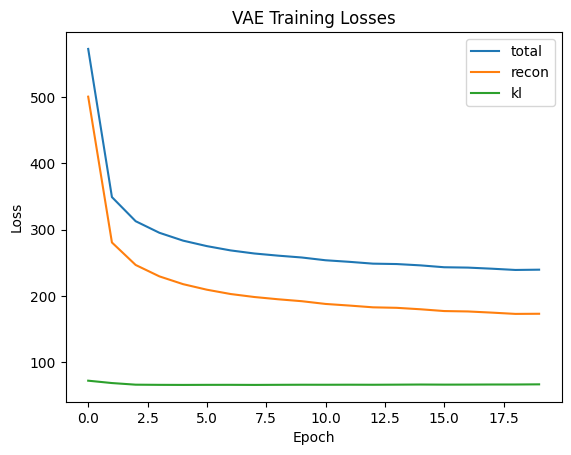

In [56]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history, label="total")
plt.plot(recon_history, label="recon")
plt.plot(kl_history, label="kl")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE Training Losses")
plt.show()

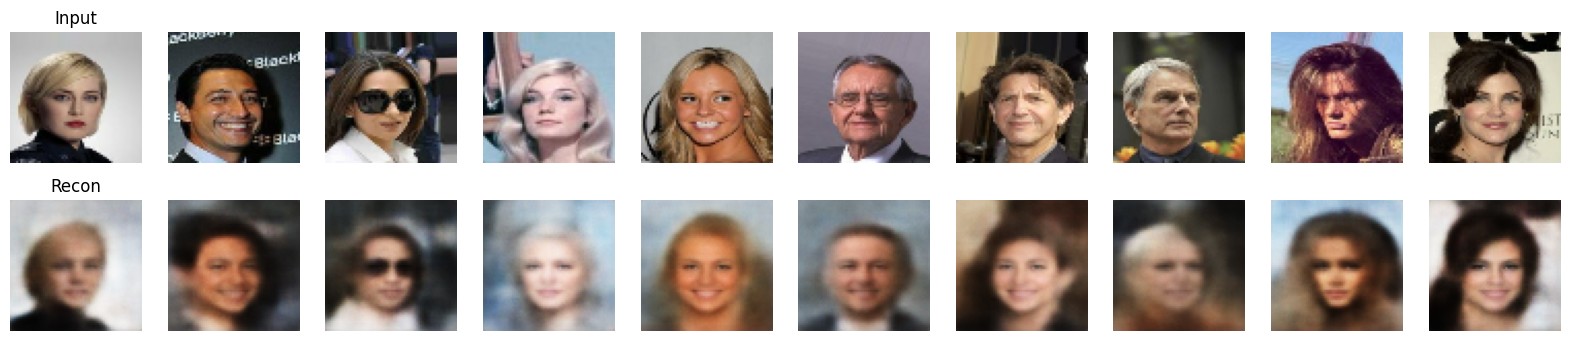

In [58]:
import matplotlib.pyplot as plt

x = next(iter(dataset))
mu, logvar = encoder(x, training=False)
eps = tf.random.normal(shape=tf.shape(mu))
z = mu + tf.exp(0.5 * logvar) * eps
x_hat = decoder(z, training=False)

# back to [0,1] for display
x_disp = x.numpy()#(x.numpy() + 1.0) / 2.0
xhat_disp = x_hat.numpy()#(x_hat.numpy() + 1.0) / 2.0

n = 10
plt.figure(figsize=(2*n, 4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(np.clip(x_disp[i], 0, 1))
    plt.axis("off")
    if i == 0: plt.title("Input")

    plt.subplot(2, n, n+i+1)
    plt.imshow(np.clip(xhat_disp[i], 0, 1))
    plt.axis("off")
    if i == 0: plt.title("Recon")

plt.show()

## Large Model (d=128)


In [43]:
LATENT_DIM = 128

enc_in = keras.Input(shape=(64,64,3))

x = layers.Conv2D(128, 4, strides=2, padding="same", use_bias=False)(enc_in)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(256, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(512, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(1024, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Flatten()(x)  # 4*4*1024

mu = layers.Dense(LATENT_DIM, name="mu")(x)
logvar = layers.Dense(LATENT_DIM, name="logvar")(x)

encoder = keras.Model(enc_in, [mu, logvar], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │      6,144 │ input_layer_8[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │    524,288 │ re_lu_16[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 8, 8, 512) │  2,097,152 │ re_lu_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 4, 4,      │  8,388,608 │ re_lu_18[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4,      │      4,096 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 4, 4,      │          0 │ batch_normalizat… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 16384)     │          0 │ re_lu_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 128)       │  2,097,280 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logvar (Dense)      │ (None, 128)       │  2,097,280 │ flatten_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,218,432 (58.05 MB)

 Trainable params: 15,214,592 (58.04 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [46]:
dec_in = keras.Input(shape=(LATENT_DIM,))

y = layers.Dense(4*4*1024)(dec_in)
y = layers.Reshape((4,4,1024))(y)

y = layers.Conv2DTranspose(512, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(256, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(3, 4, strides=2, padding="same", use_bias=True)(y)
dec_out = layers.Activation("sigmoid")(y)

decoder = keras.Model(dec_in, dec_out, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16384)          │     2,113,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (None, 8, 8, 512)      │     8,388,608 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_21             │ (None, 16, 16, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 32, 32, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 64, 64, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,133,315 (50.10 MB)

 Trainable params: 13,131,523 (50.09 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [47]:
opt = keras.optimizers.Adam(1e-4)

EPOCHS = 20

loss_history = []
recon_history = []
kl_history = []

for epoch in range(EPOCHS):
    t0 = time.time()
    total_epoch = 0.0
    recon_epoch = 0.0
    kl_epoch = 0.0
    steps = 0

    for x in dataset:
        with tf.GradientTape() as tape:
            mu, logvar = encoder(x, training=True)

            eps = tf.random.normal(shape=tf.shape(mu))
            z = mu + tf.exp(0.5 * logvar) * eps

            x_hat = decoder(z, training=True)

            # recon loss: sum over pixels, mean over batch
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_hat), axis=[1,2,3]))

            # KL loss
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, encoder.trainable_weights + decoder.trainable_weights)
        opt.apply_gradients(zip(grads, encoder.trainable_weights + decoder.trainable_weights))

        total_epoch += float(total_loss)
        recon_epoch += float(recon_loss)
        kl_epoch += float(kl_loss)
        steps += 1

    total_epoch /= steps
    recon_epoch /= steps
    kl_epoch /= steps

    loss_history.append(total_epoch)
    recon_history.append(recon_epoch)
    kl_history.append(kl_epoch)

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_epoch:.3f} recon={recon_epoch:.3f} kl={kl_epoch:.3f} | time={time.time()-t0:.1f}s")

Epoch 1/20 | loss=540.966 recon=473.252 kl=67.714 | time=40.7s
Epoch 2/20 | loss=350.797 recon=280.578 kl=70.219 | time=40.4s
Epoch 3/20 | loss=316.861 recon=249.149 kl=67.712 | time=40.1s
Epoch 4/20 | loss=299.151 recon=232.775 kl=66.375 | time=40.1s
Epoch 5/20 | loss=286.684 recon=221.015 kl=65.669 | time=39.9s
Epoch 6/20 | loss=277.760 recon=212.421 kl=65.339 | time=39.8s
Epoch 7/20 | loss=272.782 recon=207.988 kl=64.795 | time=40.0s
Epoch 8/20 | loss=266.144 recon=200.882 kl=65.263 | time=40.0s
Epoch 9/20 | loss=261.087 recon=196.167 kl=64.919 | time=39.8s
Epoch 10/20 | loss=259.079 recon=193.771 kl=65.308 | time=39.9s
Epoch 11/20 | loss=255.849 recon=190.373 kl=65.476 | time=39.8s
Epoch 12/20 | loss=252.508 recon=187.072 kl=65.437 | time=39.8s
Epoch 13/20 | loss=250.244 recon=184.643 kl=65.601 | time=40.2s
Epoch 14/20 | loss=248.900 recon=183.015 kl=65.885 | time=39.8s
Epoch 15/20 | loss=246.701 recon=180.807 kl=65.894 | time=40.5s
Epoch 16/20 | loss=245.204 recon=179.147 kl=66.05

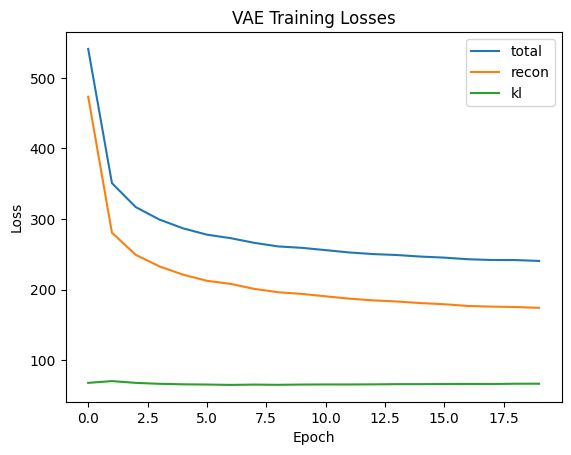

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history, label="total")
plt.plot(recon_history, label="recon")
plt.plot(kl_history, label="kl")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE Training Losses")
plt.show()

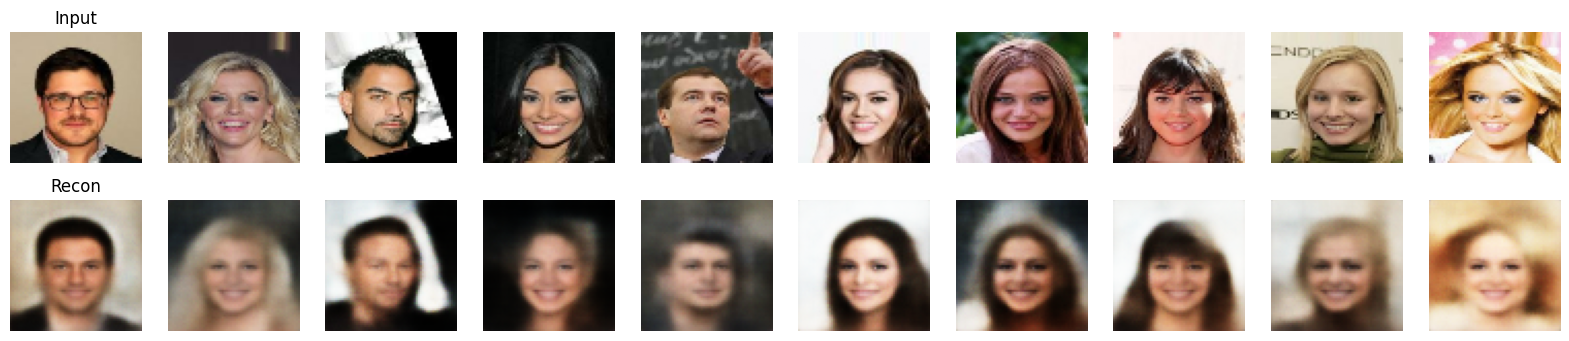

In [52]:
import matplotlib.pyplot as plt

x = next(iter(dataset))
mu, logvar = encoder(x, training=False)
eps = tf.random.normal(shape=tf.shape(mu))
z = mu + tf.exp(0.5 * logvar) * eps
x_hat = decoder(z, training=False)

# back to [0,1] for display
x_disp = x.numpy()#(x.numpy() + 1.0) / 2.0
xhat_disp = x_hat.numpy()#(x_hat.numpy() + 1.0) / 2.0

n = 10
plt.figure(figsize=(2*n, 4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(np.clip(x_disp[i], 0, 1))
    plt.axis("off")
    if i == 0: plt.title("Input")

    plt.subplot(2, n, n+i+1)
    plt.imshow(np.clip(xhat_disp[i], 0, 1))
    plt.axis("off")
    if i == 0: plt.title("Recon")

plt.show()

## Small Model (d=16)

In [64]:
LATENT_DIM = 16

enc_in = keras.Input(shape=(64,64,3))

x = layers.Conv2D(128, 4, strides=2, padding="same", use_bias=False)(enc_in)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(256, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(512, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(1024, 4, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Flatten()(x)  # 4*4*1024

mu = layers.Dense(LATENT_DIM, name="mu")(x)
logvar = layers.Dense(LATENT_DIM, name="logvar")(x)

encoder = keras.Model(enc_in, [mu, logvar], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │      6,144 │ input_layer_15[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_28 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 16, 16,    │    524,288 │ re_lu_28[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_29 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 8, 8, 512) │  2,097,152 │ re_lu_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 4, 4,      │  8,388,608 │ re_lu_30[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4,      │      4,096 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_31 (ReLU)     │ (None, 4, 4,      │          0 │ batch_normalizat… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 16384)     │          0 │ re_lu_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 16)        │    262,160 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logvar (Dense)      │ (None, 16)        │    262,160 │ flatten_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,548,192 (44.05 MB)

 Trainable params: 11,544,352 (44.04 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [65]:
dec_in = keras.Input(shape=(LATENT_DIM,))

y = layers.Dense(4*4*1024)(dec_in)
y = layers.Reshape((4,4,1024))(y)

y = layers.Conv2DTranspose(512, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(256, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(y)
y = layers.BatchNormalization()(y)
y = layers.LeakyReLU(0.2)(y)

y = layers.Conv2DTranspose(3, 4, strides=2, padding="same", use_bias=True)(y)
dec_out = layers.Activation("sigmoid")(y)

decoder = keras.Model(dec_in, dec_out, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16384)          │       278,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_8 (Reshape)             │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_32             │ (None, 8, 8, 512)      │     8,388,608 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_33             │ (None, 16, 16, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_34             │ (None, 32, 32, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_35             │ (None, 64, 64, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,298,307 (43.10 MB)

 Trainable params: 11,296,515 (43.09 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [66]:
opt = keras.optimizers.Adam(1e-4)

EPOCHS = 20

loss_history = []
recon_history = []
kl_history = []

for epoch in range(EPOCHS):
    t0 = time.time()
    total_epoch = 0.0
    recon_epoch = 0.0
    kl_epoch = 0.0
    steps = 0

    for x in dataset:
        with tf.GradientTape() as tape:
            mu, logvar = encoder(x, training=True)

            eps = tf.random.normal(shape=tf.shape(mu))
            z = mu + tf.exp(0.5 * logvar) * eps

            x_hat = decoder(z, training=True)

            # recon loss: sum over pixels, mean over batch
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_hat), axis=[1,2,3]))

            # KL loss
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, encoder.trainable_weights + decoder.trainable_weights)
        opt.apply_gradients(zip(grads, encoder.trainable_weights + decoder.trainable_weights))

        total_epoch += float(total_loss)
        recon_epoch += float(recon_loss)
        kl_epoch += float(kl_loss)
        steps += 1

    total_epoch /= steps
    recon_epoch /= steps
    kl_epoch /= steps

    loss_history.append(total_epoch)
    recon_history.append(recon_epoch)
    kl_history.append(kl_epoch)

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_epoch:.3f} recon={recon_epoch:.3f} kl={kl_epoch:.3f} | time={time.time()-t0:.1f}s")

Epoch 1/20 | loss=509.739 recon=470.699 kl=39.039 | time=40.8s
Epoch 2/20 | loss=335.509 recon=298.605 kl=36.904 | time=41.4s
Epoch 3/20 | loss=318.883 recon=282.666 kl=36.217 | time=40.7s
Epoch 4/20 | loss=309.835 recon=274.078 kl=35.758 | time=40.5s
Epoch 5/20 | loss=304.573 recon=268.960 kl=35.613 | time=41.2s
Epoch 6/20 | loss=302.828 recon=267.033 kl=35.795 | time=41.5s
Epoch 7/20 | loss=297.510 recon=262.062 kl=35.449 | time=40.9s
Epoch 8/20 | loss=294.531 recon=259.351 kl=35.180 | time=41.1s
Epoch 9/20 | loss=293.833 recon=258.396 kl=35.437 | time=41.8s
Epoch 10/20 | loss=291.212 recon=255.767 kl=35.445 | time=42.2s
Epoch 11/20 | loss=290.638 recon=255.251 kl=35.386 | time=40.8s
Epoch 12/20 | loss=286.439 recon=251.326 kl=35.113 | time=41.5s
Epoch 13/20 | loss=286.459 recon=251.156 kl=35.303 | time=41.8s
Epoch 14/20 | loss=283.646 recon=248.474 kl=35.172 | time=41.5s
Epoch 15/20 | loss=285.549 recon=250.122 kl=35.427 | time=41.3s
Epoch 16/20 | loss=282.099 recon=246.629 kl=35.47

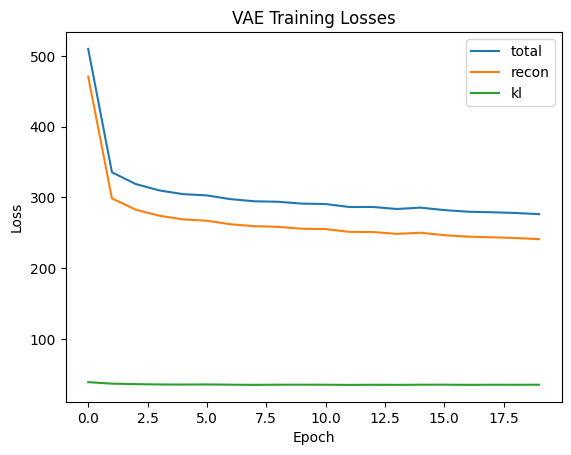

In [67]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history, label="total")
plt.plot(recon_history, label="recon")
plt.plot(kl_history, label="kl")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE Training Losses")
plt.show()

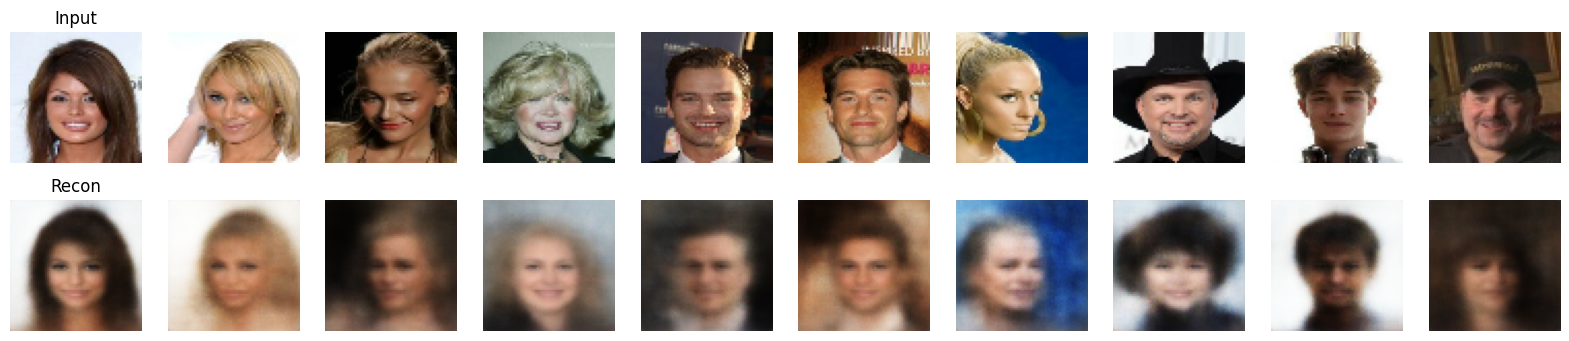

In [68]:
import matplotlib.pyplot as plt

x = next(iter(dataset))
mu, logvar = encoder(x, training=False)
eps = tf.random.normal(shape=tf.shape(mu))
z = mu + tf.exp(0.5 * logvar) * eps
x_hat = decoder(z, training=False)

# back to [0,1] for display
x_disp = x.numpy()#(x.numpy() + 1.0) / 2.0
xhat_disp = x_hat.numpy()#(x_hat.numpy() + 1.0) / 2.0

n = 10
plt.figure(figsize=(2*n, 4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(np.clip(x_disp[i], 0, 1))
    plt.axis("off")
    if i == 0: plt.title("Input")

    plt.subplot(2, n, n+i+1)
    plt.imshow(np.clip(xhat_disp[i], 0, 1))
    plt.axis("off")
    if i == 0: plt.title("Recon")

plt.show()